In [1]:
import torch
import numpy as np
import torch.nn as nn #neural networks
import torch.optim as optim # optimizer
from torch.utils.data import DataLoader

import torchvision.datasets as datasets # divide images to batches
import torchvision.transforms as transforms # work image augementation
import matplotlib.pyplot as plt # show images

In [2]:
# to downlaod datset already present in pytorch

train_set = datasets.MNIST(root="",
                            transform=transforms.ToTensor(),
                            train=True,
                            download=True)
test_set=datasets.MNIST(root="",
                            transform=transforms.ToTensor(),
                            train=False,
                            download=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 103MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 35.3MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 86.0MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.31MB/s]


In [3]:
train_set.classes

['0 - zero',
 '1 - one',
 '2 - two',
 '3 - three',
 '4 - four',
 '5 - five',
 '6 - six',
 '7 - seven',
 '8 - eight',
 '9 - nine']

In [4]:

print("Train Dataset size",train_set.data.shape)
print("Test Dataset size",test_set.data.shape)

Train Dataset size torch.Size([60000, 28, 28])
Test Dataset size torch.Size([10000, 28, 28])


In [5]:
train_loader=DataLoader(train_set,batch_size=64,shuffle=True)
test_loader=DataLoader(test_set,batch_size=64,shuffle=True)

In [6]:
 for images,labels in train_loader:
  print(images.shape)
  break


torch.Size([64, 1, 28, 28])


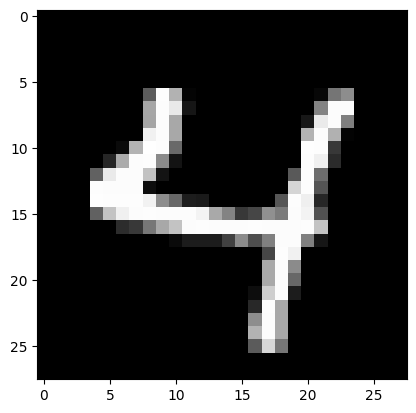

In [7]:
dataiter =iter(train_loader)
images ,labels=next(dataiter)

plt.imshow(images[1].numpy().squeeze(),cmap="gray")

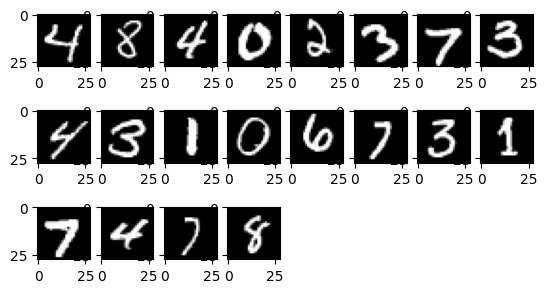

In [8]:
figure= plt.figure()
for i in range(1,21):
  plt.subplot(4,8,i)
  plt.imshow(images[i].numpy().squeeze(),cmap="gray")


In [9]:
# nn.Module is parent class ANN child class
class ANN(nn.Module):
  def __init__(self):
    super(ANN,self).__init__()

# initialised the data

    self.fc1= nn.Linear(28*28,256)
    self.fc2= nn.Linear(256,128)
    self.fc3= nn.Linear(128,64)
    self.fc4= nn.Linear(64,10)

    # activation function for hidden layer
    self.reLu=nn.ReLU()
    self.softmax=nn.Softmax() # for output activation function , convert discrete to probabilities, higher probability that is output

    #reshaping the image into 1D from 2D

  def forward(self,img):
    out=img.view(-1,28*28*1)
    out=self.fc1(out)
    out=self.reLu(out)
    out=self.fc2(out)
    out=self.reLu(out)
    out=self.fc3(out)
    out=self.reLu(out)
    out=self.fc4(out)
    #out=self.softmax(out)

    return out






In [10]:
model=ANN()

In [11]:
print(model)

ANN(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=64, bias=True)
  (fc4): Linear(in_features=64, out_features=10, bias=True)
  (reLu): ReLU()
  (softmax): Softmax(dim=None)
)


In [12]:
# focused on particular region which is to be detected but in ANN whole image is converted to pixels and whole image is being consider
class CNN(nn.Module):
  def __init__(self):
    super(CNN,self).__init__()


    self.conv1=nn.Conv2d(in_channels=1,out_channels=16,kernel_size=3)  #in_channel= 1 for black and white 3 for colours , kernel_size or images size= 3
    self.conv2=nn.Conv2d(in_channels=16,out_channels=32,kernel_size=3)
    self.pool=nn.MaxPool2d(2)  #reducing size of img
    self.relu=nn.ReLU()
    self.fc1 = nn.Linear(32 * 5 * 5, 10)  #hidden layer is ANN output 10 but input we need maths so


  def forward(self,img):
    out=self.conv1(img)   # n-f+2p/s +1 n=dimension f =kernel size p= padding s = stride  (28-3+2*0/1 +1= 26*26*16) depth = output chnnel
    out=self.relu(out)
    out=self.pool(out)   #reduce no of chnnel output wiil be or dimension of img reduce 13*13*16 depth doesnot
    out=self.conv2(out)  #13-3 +2*0/1 +1 = 11*11*32
    out=self.relu(out)
    out=self.pool(out)   #5*5*32
    out=out.view(-1,32*5*5)   #resize this
    out=self.fc1(out)


    return out



In [13]:
model=CNN()
print(model)

CNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (fc1): Linear(in_features=800, out_features=10, bias=True)
)


In [14]:
class RNN(nn.Module):
  def __init__(self,input_size=28,sequence_len=28,hidden_size=256,num_layers=2,num_classes=10):
    super(RNN,self).__init__()

    self.hidden_size=hidden_size
    self.num_layers=num_layers

    self.lstm= nn.LSTM(input_size,hidden_size,num_layers,batch_first=True)
    self.fc=nn.Linear(sequence_len*hidden_size,num_classes)

  def forward(self, img):
    img = img.squeeze(1)  # [B, 1, 28, 28] → [B, 28, 28]

    h0 = torch.zeros(self.num_layers, img.size(0), self.hidden_size).to(img.device)
    c0 = torch.zeros(self.num_layers, img.size(0), self.hidden_size).to(img.device)

    out, _ = self.lstm(img, (h0, c0))  # [B, 28, 256]
    out = out.reshape(out.shape[0], -1)  # flatten: [B, 28*256]
    out = self.fc(out)  # [B, 10]

    return out



In [15]:
rnn=RNN()
print(rnn)

RNN(
  (lstm): LSTM(28, 256, num_layers=2, batch_first=True)
  (fc): Linear(in_features=7168, out_features=10, bias=True)
)


In [16]:
loss_fn=nn.CrossEntropyLoss()
optimizer=optim.SGD(model.parameters(),lr=0.001)

In [29]:
def train(model, loss_fn, optimizer, epochs=10):
    training_acc = []
    training_loss = []
    testing_acc = []
    testing_loss = []

    for epoch in range(epochs):
        train_loss = 0.0
        train_acc = 0.0
        model.train()

        for images, labels in train_loader:
            optimizer.zero_grad()
            output = model(images)
            loss = loss_fn(output, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            prediction = torch.argmax(output, 1)
            train_acc += torch.sum(prediction == labels).item()

        training_loss.append(train_loss / len(train_loader))
        training_acc.append(train_acc / len(train_set))

        model.eval()
        test_loss = 0.0
        test_acc = 0.0

        with torch.no_grad():
            for images, labels in test_loader:
                output = model(images)
                loss = loss_fn(output, labels)
                test_loss += loss.item()
                prediction = torch.argmax(output, 1)
                test_acc += torch.sum(prediction == labels).item()

        testing_acc.append(test_acc / len(test_set))
        testing_loss.append(test_loss / len(test_loader))

        print("Epoch {}, Training Acc {:.2f}, Testing Acc {:.2f}, Training Loss {:.2f}, Testing Loss {:.2f}".format(
            epoch + 1,
            train_acc / len(train_set),
            test_acc / len(test_set),
            train_loss / len(train_loader),
            test_loss / len(test_loader)
        ))

 # plot training & testing curver
    plt.title("Training Curve & Testing vs Epochs")
    plt.plot(range(epochs),training_acc,label="Training Acc")
    plt.plot(range(epochs),testing_acc,label="Testing Acc")
    plt.legend()
    plt.xlabel("Epochs")
    plt.ylabel("Training & Testing Accuracy")
    plt.show()


        #plot for training and testing loss

    plt.title("Training  & Testing  loss vs Epochs")
    plt.plot(range(epochs),training_loss,label="Training loss")
    plt.plot(range(epochs),testing_loss,label="Testing loss")
    plt.legend()
    plt.xlabel("Epochs")
    plt.ylabel("Training & Testing Loss")
    plt.show()







Epoch 1, Training Acc 0.11, Testing Acc 0.13, Training Loss 2.30, Testing Loss 2.30
Epoch 2, Training Acc 0.17, Testing Acc 0.19, Training Loss 2.30, Testing Loss 2.29
Epoch 3, Training Acc 0.19, Testing Acc 0.20, Training Loss 2.29, Testing Loss 2.28
Epoch 4, Training Acc 0.20, Testing Acc 0.21, Training Loss 2.28, Testing Loss 2.27
Epoch 5, Training Acc 0.22, Testing Acc 0.25, Training Loss 2.26, Testing Loss 2.25
Epoch 6, Training Acc 0.33, Testing Acc 0.41, Training Loss 2.24, Testing Loss 2.23
Epoch 7, Training Acc 0.42, Testing Acc 0.44, Training Loss 2.21, Testing Loss 2.18
Epoch 8, Training Acc 0.43, Testing Acc 0.45, Training Loss 2.15, Testing Loss 2.12
Epoch 9, Training Acc 0.46, Testing Acc 0.48, Training Loss 2.07, Testing Loss 2.02
Epoch 10, Training Acc 0.49, Testing Acc 0.50, Training Loss 1.96, Testing Loss 1.88


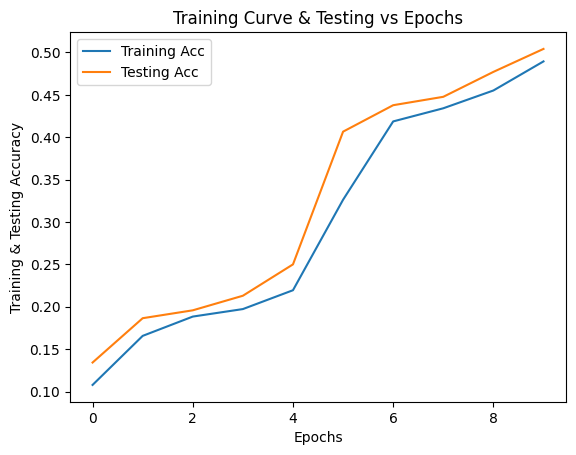

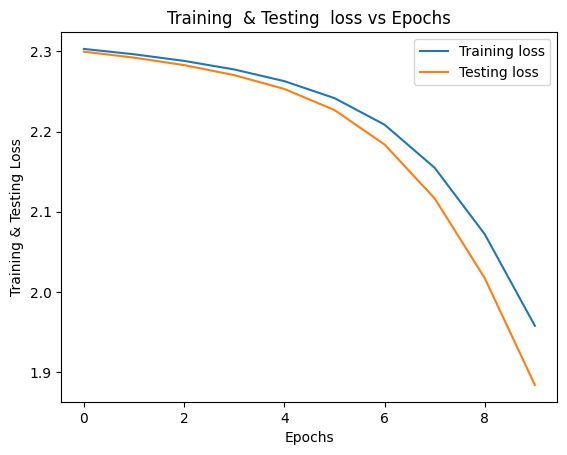

In [30]:
model=ANN()
loss_fn=nn.CrossEntropyLoss()
optimizer=optim.SGD(model.parameters(),lr=0.001)
train(model,loss_fn,optimizer)

Epoch 1, Training Acc 0.16, Testing Acc 0.31, Training Loss 2.28, Testing Loss 2.23
Epoch 2, Training Acc 0.52, Testing Acc 0.69, Training Loss 2.15, Testing Loss 1.98
Epoch 3, Training Acc 0.74, Testing Acc 0.80, Training Loss 1.56, Testing Loss 1.01
Epoch 4, Training Acc 0.82, Testing Acc 0.85, Training Loss 0.76, Testing Loss 0.57
Epoch 5, Training Acc 0.86, Testing Acc 0.88, Training Loss 0.53, Testing Loss 0.45
Epoch 6, Training Acc 0.87, Testing Acc 0.88, Training Loss 0.45, Testing Loss 0.40
Epoch 7, Training Acc 0.88, Testing Acc 0.89, Training Loss 0.40, Testing Loss 0.37
Epoch 8, Training Acc 0.89, Testing Acc 0.90, Training Loss 0.38, Testing Loss 0.34
Epoch 9, Training Acc 0.90, Testing Acc 0.90, Training Loss 0.36, Testing Loss 0.33
Epoch 10, Training Acc 0.90, Testing Acc 0.91, Training Loss 0.34, Testing Loss 0.31


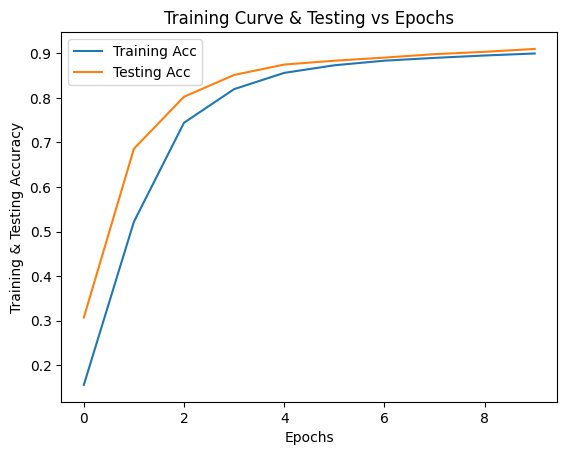

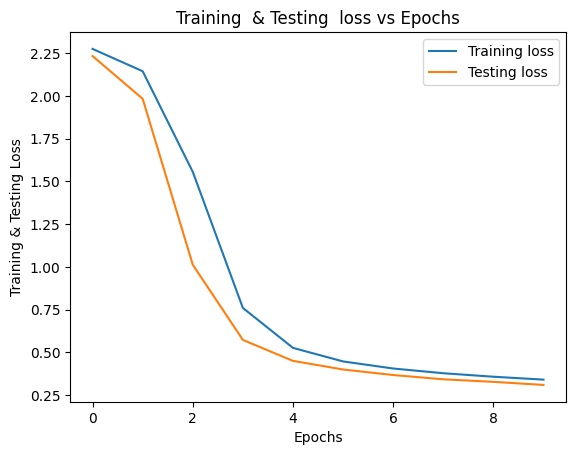

In [31]:
model=CNN()
loss_fn=nn.CrossEntropyLoss()
optimizer=optim.SGD(model.parameters(),lr=0.001)
train(model,loss_fn,optimizer)

Epoch 1, Training Acc 0.11, Testing Acc 0.11, Training Loss 2.30, Testing Loss 2.30
Epoch 2, Training Acc 0.11, Testing Acc 0.11, Training Loss 2.29, Testing Loss 2.29
Epoch 3, Training Acc 0.11, Testing Acc 0.12, Training Loss 2.29, Testing Loss 2.28
Epoch 4, Training Acc 0.13, Testing Acc 0.15, Training Loss 2.28, Testing Loss 2.28
Epoch 5, Training Acc 0.16, Testing Acc 0.20, Training Loss 2.27, Testing Loss 2.27
Epoch 6, Training Acc 0.22, Testing Acc 0.27, Training Loss 2.26, Testing Loss 2.26
Epoch 7, Training Acc 0.29, Testing Acc 0.32, Training Loss 2.25, Testing Loss 2.24
Epoch 8, Training Acc 0.34, Testing Acc 0.39, Training Loss 2.24, Testing Loss 2.22
Epoch 9, Training Acc 0.40, Testing Acc 0.43, Training Loss 2.21, Testing Loss 2.19
Epoch 10, Training Acc 0.44, Testing Acc 0.46, Training Loss 2.18, Testing Loss 2.15


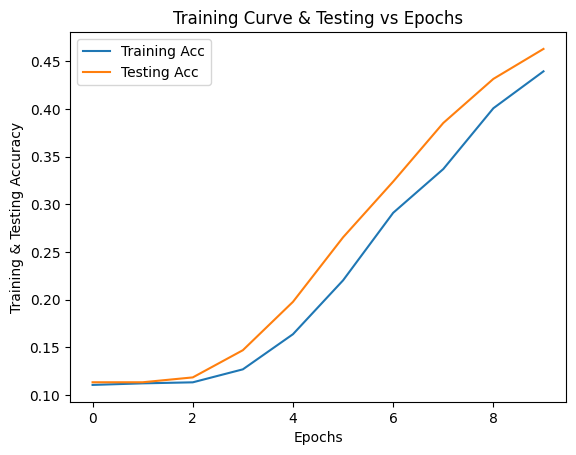

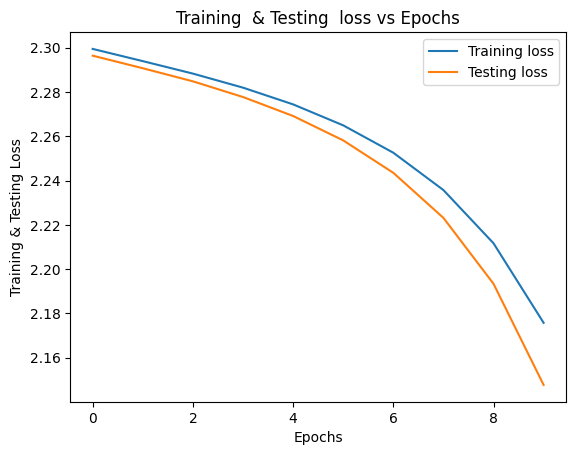

In [32]:
model=RNN()
loss_fn=nn.CrossEntropyLoss()
optimizer=optim.SGD(model.parameters(),lr=0.001)
train(model,loss_fn,optimizer)